<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Padding, Stride, Pooling, Activation**


## **Introduction**

In the image convolution lab, we learned that kernels can detect visual patterns such as edges, corners, and textures. The inserted image above introduces four important settings and operations used in Convolutional Neural Networks (CNNs): **padding**, **stride**, **pooling**, and **activation**.

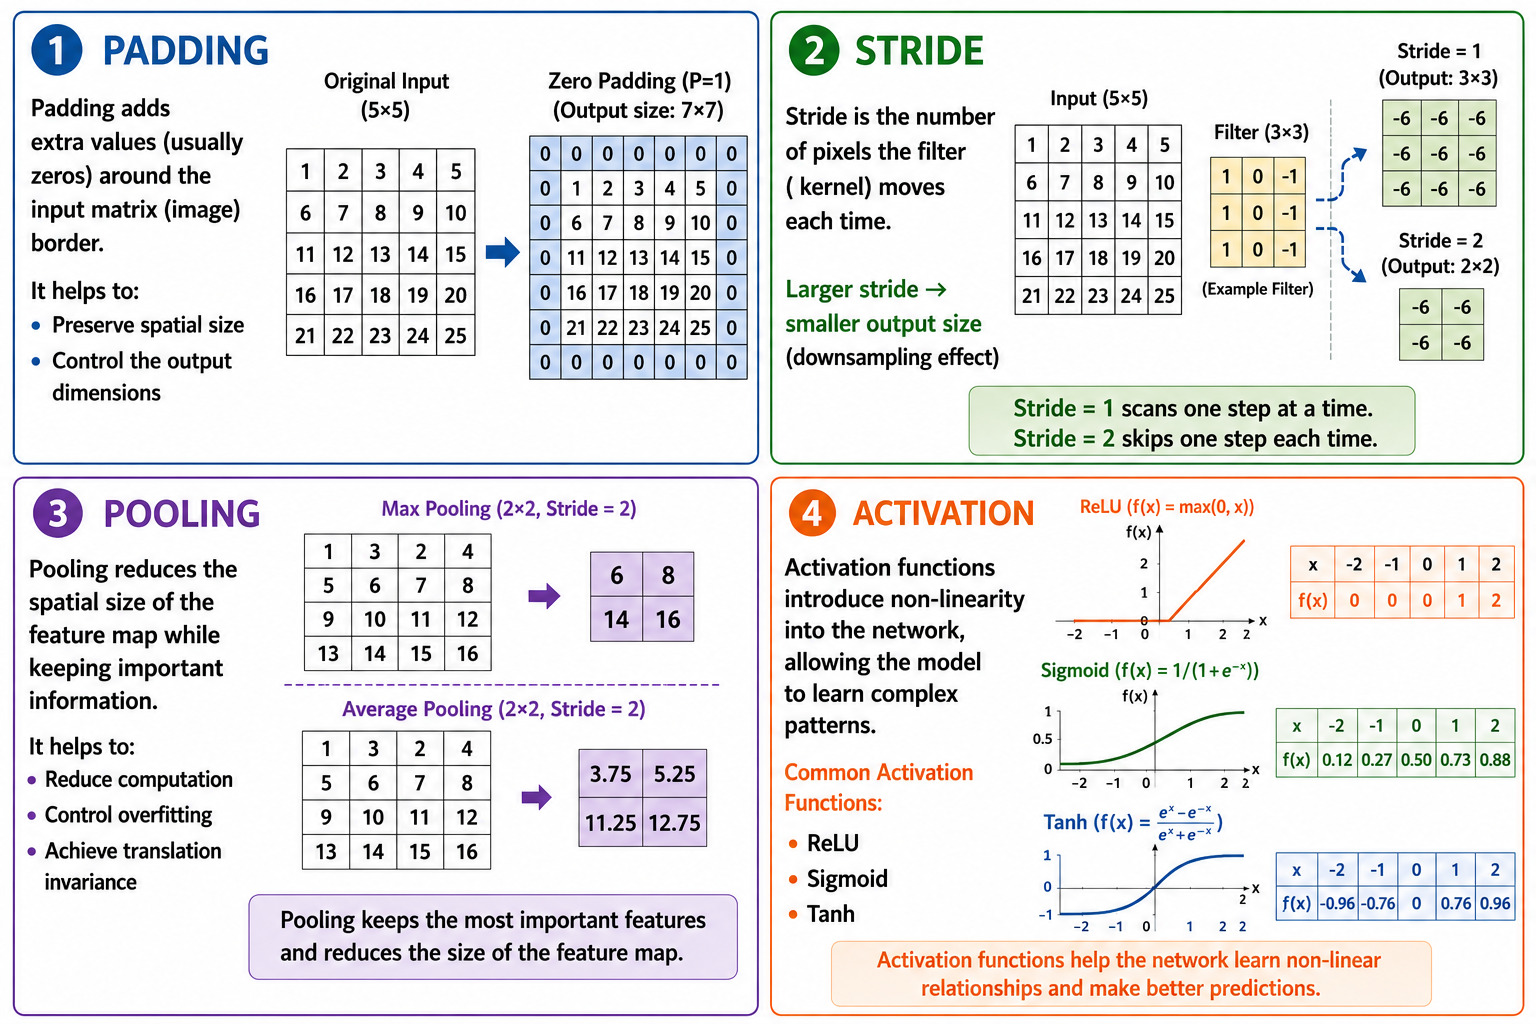

**Padding** adds extra values around the border of an image. This helps preserve edge information and control the output size after convolution.

**Stride** controls how far the kernel moves each time. A larger stride skips more pixels and usually creates a smaller output feature map.

**Pooling** reduces the size of a feature map while keeping important information. Max pooling keeps the largest value in each region, while average pooling keeps the average value.

**Activation functions** add non-linearity to the network. This helps the model learn more complex patterns than convolution alone can capture.

In this lab, you will study how these four ideas affect the shape, information, and behavior of CNN feature maps.


## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
    3. [Defining Helper Functions](#toc-defining-helper-functions)
3. [Padding and Stride](#toc-padding-and-stride)
    1. [Background](#toc-background)
    2. [How does Padding work?](#toc-how-does-padding-work)
    3. [Use Padding in Tensorflow.Keras](#toc-use-padding-in-tensorflow-keras)
    4. [How does Stride work?](#toc-how-does-stride-work)
    5. [Example 1: Image Processing - Edge Detection](#toc-example-1-image-processing-edge-detection)
4. [Activation](#toc-activation)
    1. [Example 2: Feature Detection with Kernel and Activation](#toc-example-2-feature-detection-with-kernel-and-activation)
5. [Pooling](#toc-pooling)
    1. [What is Pooling?](#toc-what-is-pooling)
    2. [Example 3: Max or Average?](#toc-example-3-max-or-average)
6. [Exercises](#toc-exercises)
    1. [Exercise 1 - Display some images](#toc-exercise-1-display-some-images)
    2. [Exercise 2 - Set up a Convolution layer](#toc-exercise-2-set-up-a-convolution-layer)
    3. [Exercise 3 - Set up a Max pooling layer](#toc-exercise-3-set-up-a-max-pooling-layer)
    4. [Exercise 4 - Create a deeper CNN with blocks](#toc-exercise-4-create-a-deeper-cnn-with-blocks)
    5. [Optional section](#toc-optional-section)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

 - Understand the use of padding and stride in CNN
 - Calculate the size of the output of a layer
 - Understand the necessity of activations
 - Describe the difference between Max pooling and Average Pooling


----


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [2]:
#!mamba install -qy tqdm

In [3]:
#!pip install --upgrade tensorflow

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

_We recommend you import all required libraries in one place (here):_


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits, load_wine

import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import PIL
from PIL import Image, ImageOps
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, datasets
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import AveragePooling2D

sns.set_context('notebook')
sns.set_style('white')

### **Defining Helper Functions** <a id="toc-defining-helper-functions"></a>


The Sobel operator for edge detection **v_grad** and **h_grad** will be defined later.


In [5]:
# This function will allow us to easily plot data taking in x values, y values, and a title
def sobel(img, strides, padding, activation=None):

    input_layer = layers.Input(shape=(img_height, img_width, 1))

    v_conv = layers.Conv2D(
        filters=1,
        kernel_size=3,
        kernel_initializer=v_grad,
        strides=strides,
        padding=padding,
        activation=None,
    )
    h_conv = layers.Conv2D(
        filters=1,
        kernel_size=3,
        kernel_initializer=h_grad,
        strides=strides,
        padding=padding,
        activation=None,
    )

    v_model = keras.Sequential([input_layer, v_conv])
    h_model = keras.Sequential([input_layer, h_conv])

    Gx = h_model.predict(img, verbose=0)[0, :, :, 0]
    Gy = v_model.predict(img, verbose=0)[0, :, :, 0]
    G = np.sqrt(np.add(np.multiply(Gx, Gx), np.multiply(Gy, Gy)))

    return G

## **Padding and Stride** <a id="toc-padding-and-stride"></a>


### **Background** <a id="toc-background"></a>


In our previous lab on image convolution, we saw that pixels near the border of an image are often lost during convolution. This happens because the kernel cannot fully overlap the edge pixels, since there are not enough surrounding pixels for the matrix multiplication.

As we stack multiple convolution layers, the output image becomes smaller and more border information is lost. This can reduce CNN performance because important image features near the edges may disappear.

To preserve border information and better control the output size of the convolution, CNNs commonly use two techniques called **padding** and **stride**.

<a id="toc-how-does-padding-work"></a>
### **How does Padding work?** 

Padding adds extra pixels around the border of an image before convolution. These added pixels are usually zeros, so this method is often called **zero padding**.
The main purpose of padding is to preserve information near the edges of the image. Without padding, border pixels are used less often because the kernel cannot fully overlap the image edges. As a result, important edge information may gradually disappear after multiple convolution layers.

By adding padding, border pixels can also appear near the center of the kernel window as it slides across the image. This helps the CNN retain more image information and better preserve important features.

The figure below shows a $3\times3$ image with a $3\times3$ kernel and one layer of padding added on all four sides:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/pad1_blue_.jpg" width="50%"></center>

After padding is added, the kernel can slide across the entire image while still covering the border pixels. In this example, the output image keeps the same size as the input image:

$$
3 \times 3
$$

In general, if we add $p_r$ rows of padding and $p_c$ columns of padding to an input image of size $m \times n$, then applying a $k \times k$ kernel produces an output image with shape:

$$
(m + p_r - k + 1) \times (n + p_c - k + 1)
$$

This formula shows how padding affects the output size after convolution.

If we want the output image to have the same size as the input image, the total padding must satisfy:

$$
p_r = k - 1
$$

and

$$
p_c = k - 1
$$

For example, with a $3 \times 3$ kernel:

$$
p_r = p_c = 2
$$

This means we add one row of padding to the top and bottom, and one column of padding to the left and right.

Padding is usually added symmetrically so that the kernel remains centered around each pixel during convolution. For this reason, CNNs commonly use odd-sized kernels such as:

$$
3 \times 3,\ 5 \times 5,\ 7 \times 7
$$

Odd kernel sizes provide a clear center pixel, which makes convolution more balanced and mathematically consistent.

### **Use Padding in Tensorflow.Keras** <a id="toc-use-padding-in-tensorflow-keras"></a>

In Keras, the operation of padding is specified via the `padding` argument in `keras.layers.Conv2D`. 

- The default is `padding = 'valid'`, which means no padding. 

- Setting `padding = 'same'` will calculate the required padding size such that the input and output will have the same shape and also add the padding, given an input and a kernel size.

The example below adds padding to a convolutional layer:


In [6]:
from keras.models import Sequential
from keras.layers import Conv2D

model = Sequential()
model.add(
    Conv2D(
        filters=1, kernel_size=(3, 3), padding="same", input_shape=(10, 10, 1)
    )
)
model.summary()

E0000 00:00:1779913961.440517  926852 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779913961.448446  926852 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 10, 10, 1)      │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

So we built a simple CNN model with one convolution layer, where we specified an input shape of $10\times10$ with one channel and the kernel applied is $3\times3$. Via padding, the output shape is also $10\times10$!


### **How does Stride work?** <a id="toc-how-does-stride-work"></a>


In the previous example, we defaulted to shifting the kernel window one pixel at a time across the image left to right, top to bottom. However, sometimes for computational efficiency or because we simply wish to downsample, we could choose to move the kernel window more than one pixel at a time. 

The number of rows and columns traversed per slide is referred to as the **Stride**. In Keras, we could specify the stride in `keras.layers.Conv2D` via the `strides` argument, as a tuple of 2 integers. For example, `strides = (2,3)` means we shift the kernel 2 pixels right for each horizontal movement and 3 pixels down for each vertical movement. 

**Combining the concept of Padding and Stride**, if we add a total of $p_r$ rows of padding and $p_c$ columns of padding to a $m\times n$ input, the output shape after applying a $k\times k$ kernel with $(s_r, s_c)$ stride will be:

$$[(m+p_r-k) / s_r+1]\times [(n+p_c-k) / s_c+1]$$


To illustrate, the full convolution process using one $3\times3$ kernel on a $3\times3$ input image with padding in place and `strides = (2,2)` looks like:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/paddingstride.gif" width="85%"></center>

We can code this in Keras:


In [7]:
model = Sequential()
model.add(
    Conv2D(
        filters=1,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding="same",
        input_shape=(3, 3, 1),
    )
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 1)        │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

So the output shape calculated by Keras is indeed $2\times2\times1$, where the one indicates the output channel (because we only applied one kernel). 

We can code the input image array and the $3\times3$ kernel, and then use a simple CNN with one **Conv2D** layer to predict the output values.

**NOTE:** Before feeding the input into the CNN, we need to reshape it so that the first **1** represents the batch size and the last **1** represents the number of channels the input contains.


In [8]:
input_ = np.array([[1, 1, 3], [2, 1, 2], [3, 1, 4]]).reshape(1, 3, 3, 1)

kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]).reshape(
    3, 3, 1, 1
)  # reshaping the kernel is important

b = np.array([0.0])

model.set_weights([kernel, b])
output_ = model.predict(input_)

for r in range(output_.shape[1]):
    print([output_[0, r, c, 0] for c in range(output_.shape[2])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[-2.0, 2.0]
[-2.0, 2.0]


**With the same input and kernel, the output matrix of our CNN is the same as the one shown in the animated gif.**


### **Example 1: Image Processing - Edge Detection** <a id="toc-example-1-image-processing-edge-detection"></a>

In the last image convolution lab, you learnt about the Sobel Operator which uses two kernels to convolve with an image to perform edge detection. In this example, we will use the Sobel Operator to detect edges in the image of the [Leaning Tower of Pisa](https://pxhere.com/en/photo/1027167) with padding and stride.


Let's first define the two kernels used for the [Sobel Operator](https://en.wikipedia.org/wiki/Sobel_operator):


In [9]:
# Lets define our custom kernels for the horizontal and vertical gradients
def v_grad(shape, dtype=None):
    # Here we use a single numpy array to define our x gradient kernel
    grad = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]).reshape((3, 3, 1, 1))
    # this line is quite important, we are saying we want one 3x3 kernel each for one channel of pixels (grayscale)

    # We check to make sure the shape of our kernel is the correct shape
    # according to the initialization of the Convolutional layer below
    assert grad.shape == shape
    return keras.backend.variable(grad, dtype="float32")


def h_grad(shape, dtype=None):
    grad = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]]).reshape((3, 3, 1, 1))

    assert grad.shape == shape
    return keras.backend.variable(grad, dtype="float32")

Download the image and display it.


In [10]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/pisa.jpg"

--2026-05-27 16:32:41--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/pisa.jpg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 762548 (745K) [image/jpeg]
Saving to: ‘pisa.jpg.4’

pisa.jpg.4          100%[===================>] 744.68K  1.39MB/s    in 0.5s    

2026-05-27 16:32:42 (1.39 MB/s) - ‘pisa.jpg.4’ saved [762548/762548]



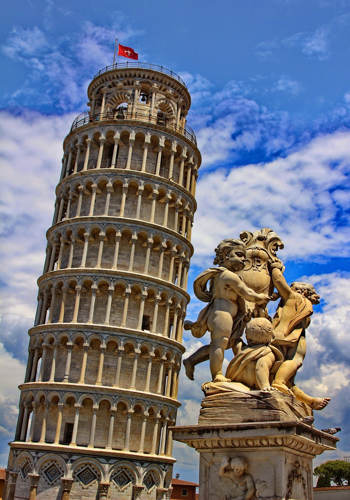

In [11]:
img_width = 350
img_height = 500
img = PIL.Image.open("pisa.jpg").resize((img_width, img_height))
img

Now we set `padding = 'same'` and try different values of `strides` for convolving the two kernels of the Sobel operator over the image. We will use the pre-defined function **sobel**.


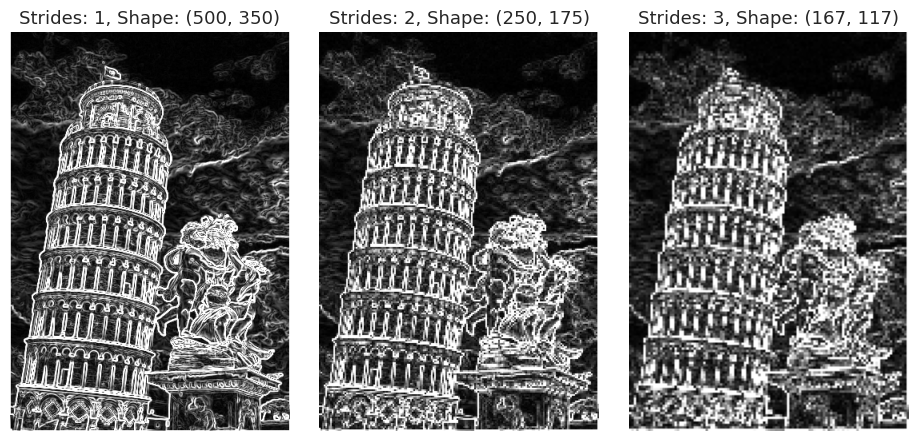

In [12]:
input_img = ImageOps.grayscale(img)
input_img = np.array(input_img).reshape((1, img_height, img_width, 1))

fig, axs = plt.subplots(1, 3, figsize=(9, 10), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0.1)

for i, ax in enumerate(axs.flat):
    output = (
        sobel(img=input_img, padding="same", strides=i + 1)
        .astype("int")
        .clip(0, 255)
    )

    ax.imshow(output, cmap="gray")
    ax.set_title(f"Strides: {i+1}, Shape: {output.shape}", fontsize=13)
    ax.axis("off")

When the `stride` value increases, the convolution kernel moves across the image in larger steps.

For example:

- `stride = 1` moves the kernel one pixel at a time
- `stride = 2` moves the kernel two pixels at a time

Larger strides reduce the size of the output image because the kernel visits fewer locations.

For example, with a `5×5` image and a `3×3` kernel:

- `stride = 1` produces more output positions
- `stride = 2` skips positions and produces a smaller output

As stride increases, the CNN samples the image less densely. This reduces computational cost and memory usage, but some fine details may be missed.

In edge detection, small strides preserve detailed boundaries because the kernel examines nearby pixels carefully. Larger strides skip over pixels, so detected edges may become less sharp or blurry.

Therefore, choosing the stride value is a tradeoff:

- smaller strides preserve more spatial detail
- larger strides reduce computation and output size

The best stride value depends on the specific task and the amount of image detail that needs to be preserved.

## **Activation** <a id="toc-activation"></a>


Recall from our previous convolution examples that the output matrix may contain negative values such as `-2`. However, image pixel values are usually expected to fall within a limited range such as:

$$
0 \text{ to } 255
$$

To make CNN outputs more suitable for further processing, **convolution layers are typically followed by an activation function**.

Activation functions serve two important purposes. 
1. they help control or transform the output values of the convolution layer. 
2. and more importantly, they introduce **non-linearity** into the network. Without non-linearity, a neural network would behave like a simple linear model and would not be able to learn complex image patterns.

In `tensorflow.keras.layers.Conv2D`, the activation function can be specified using the `activation` argument:

```python
Conv2D(filters=32, kernel_size=(3,3), activation='relu')
```


Currently, there are many types of activations existing, such as Sigmoid, Tanh, ReLU, ..., etc. For example, the famous **Sigmoid activation** function is defined as follows:

$$
f(x) = \frac{1}{1 + e^{-x}}
$$

It converts any input value into a number between:

$$
0 \text{ and } 1
$$

where:

- large positive values become close to `1`
- large negative values become close to `0`
- `x = 0` becomes `0.5`

Sigmoid is commonly used to convert neural network outputs into probabilities.

We can code the sigmoid function using numpy:


Text(0, 0.5, 'Sigmoid(x)')

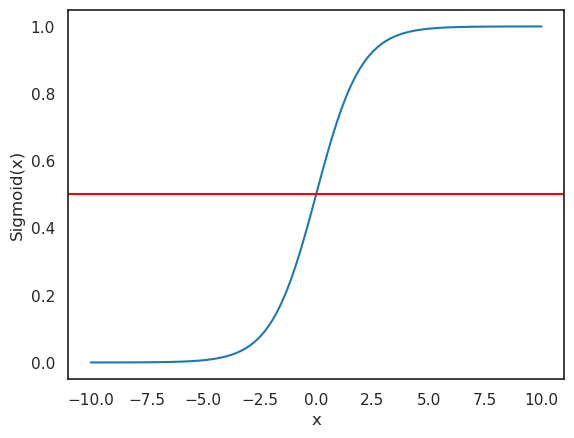

In [13]:
def sigmoid(X):

    return 1 / (1 + np.exp(-X))


X = np.linspace(-10, 10, 100)
sigmoid_X = sigmoid(X)
plt.plot(X, sigmoid_X)
plt.axhline(y=0.5, color="r", linestyle="-")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")

The sigmoid function is often called a **squashing function** because it compresses any input value into the range:

$$
0 \text{ to } 1
$$

The input to the sigmoid function is usually the weighted sum of outputs from the previous layer. Large positive inputs become values close to `1`, while large negative inputs become values close to `0`.

Many other activation functions also exist, but in this lab we will focus on the **ReLU** activation function, which is widely used in Convolutional Neural Networks (CNNs).

ReLU, or **Rectified Linear Unit**, is defined as:

$$
f(x) = \max(0, x)
$$

where $x$ is the output matrix after convolution.

ReLU keeps positive values unchanged and converts all negative values to zero. This helps the network learn complex patterns while keeping the computation simple and efficient.

We can implement the ReLU activation function using NumPy:

Text(0, 0.5, 'Relu(x)')

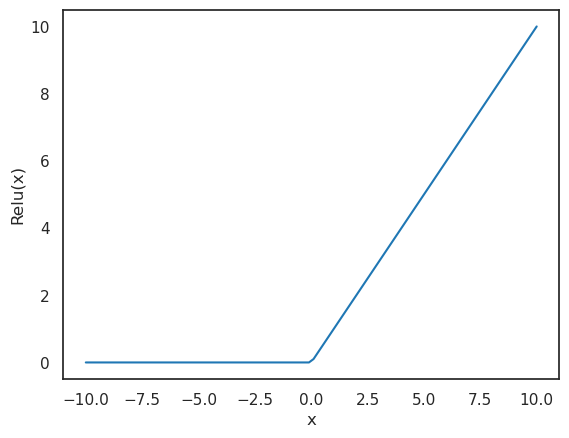

In [14]:
def relu(X):
    return np.maximum(0, X)


X = np.linspace(-10, 10, 100)
relu_X = relu(X)
plt.plot(X, relu_X)
plt.xlabel("x")
plt.ylabel("Relu(x)")

### **Example 2: Feature Detection with Kernel and Activation** <a id="toc-example-2-feature-detection-with-kernel-and-activation"></a>

In this example, instead of using the Sobel operator for edge detection, we will convolve a simple kernel over all three channels of a RGB image for the same purpose. This means our final result of edge detection will no longer be a boring, grayscale image, but a colorful and exciting one!

Specifically, we will use the following kernel:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
$$

Note that the kernel we will be using contains negative values, therefore we should specify an activation function (namely **ReLu**) in our Conv2D layer to filter out the negative values.

Let's download the image first!


In [15]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/lambor.jpeg"

--2026-05-27 16:32:43--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/lambor.jpeg
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278538 (272K) [image/jpeg]
Saving to: ‘lambor.jpeg.3’

lambor.jpeg.3       100%[===================>] 272.01K   704KB/s    in 0.4s    

2026-05-27 16:32:44 (704 KB/s) - ‘lambor.jpeg.3’ saved [278538/278538]



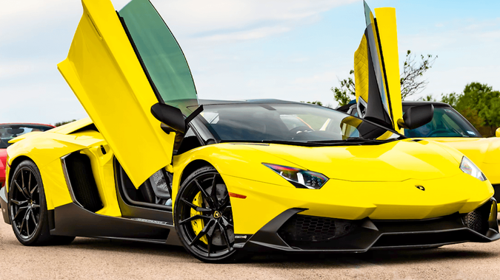

In [16]:
img_width = 500
img_height = 280

img = Image.open("lambor.jpeg").resize((img_width, img_height))
img

As we will be convolving the kernel over each channel, we need to split the RGB image into three channels or three grayscale images.

Let's display the three channels:


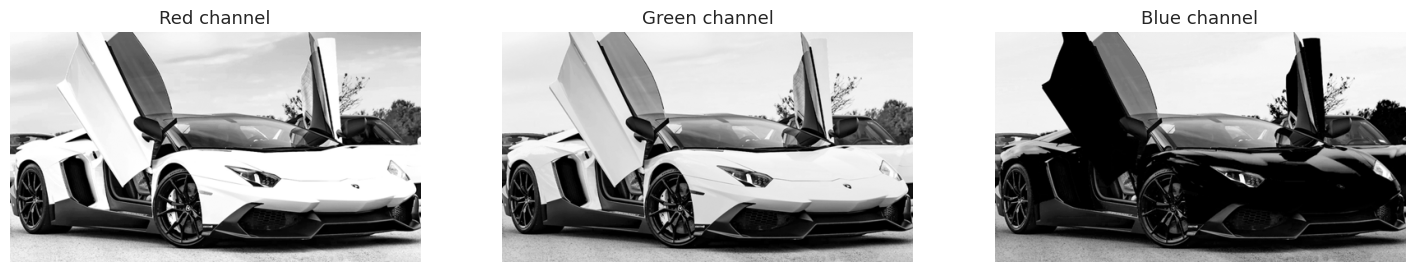

In [17]:
arr = np.array(img)
red_c = arr[:, :, 0]
green_c = arr[:, :, 1]
blue_c = arr[:, :, 2]

channels = [red_c, green_c, blue_c]
names = ["Red", "Green", "Blue"]

plt.figure(figsize=(18, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(channels[i], cmap="gray")
    plt.axis("off")
    plt.title(f"{names[i]} channel", fontsize=13)

You can see that the color of the car is mostly coming from the red and green channel, and very little from the blue channel.

Now we build a simple CNN with one Conv2D layer, using the kernel specified above as the weights.


In [18]:
kernel = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]).reshape(3, 3, 1, 1)
b = np.array([0.0])

model = keras.Sequential()
model.add(
    layers.Conv2D(
        input_shape=(img_height, img_width, 1),
        filters=1,
        kernel_size=3,
        padding="same",
        activation="relu",
    )
)
model.set_weights([kernel, b])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 280, 500, 1)    │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

`set_weights()` manually replaces the randomly initialized weights of the CNN layer with predefined values.

```python
model.set_weights([kernel, b])
```
Here:

- `kernel` is the convolution filter
- `b` is the bias term

So instead of learning weights during training, the CNN directly uses the filter:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
$$

This is a classical edge-detection filter called a **Laplacian filter**. It highlights regions where pixel values change sharply, which usually corresponds to edges.

Although the model uses:

```python
filters=1
```

it can still detect edges because one filter is enough to detect one type of feature. In this example, the single filter is specifically designed for edge detection.

The CNN therefore produces one feature map showing the detected edges in the image.

**NOTE:** In real CNNs, we usually use many filters:
```python id="l8ccw7"
Conv2D(filters=32, ...)
```

because different filters can learn different visual patterns such as edges, textures, curves, or blobs.

Once we initialize our CNN, we can now use it to predict the edge detection result for each of the R, G, B channel's gray image! 

Don't worry if the predicted results look almost all-black to you. Remember we used the ReLu activation to set all the negative pixel values to 0. In each channel, if the pixel value is 0, the pixel will appear black. Only the important information will be kept.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


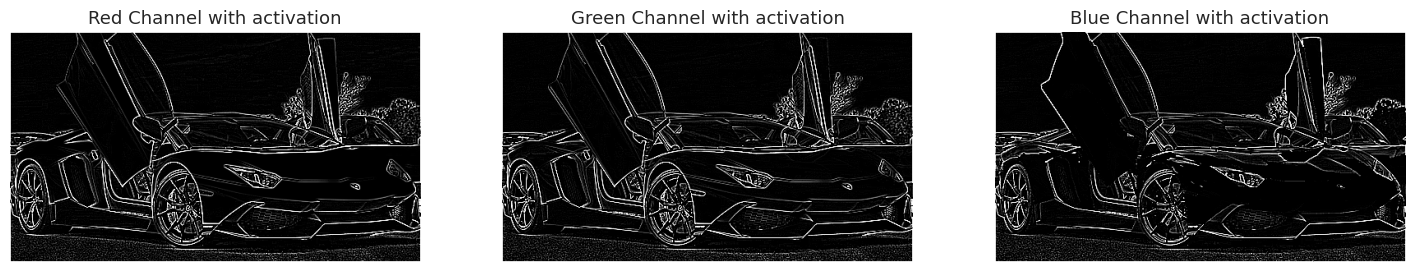

In [19]:
acts = []
plt.figure(figsize=(18, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)

    # loop through each channel
    input_ = channels[i].reshape((1, img_height, img_width, 1))
    act = model.predict(input_).squeeze(0).squeeze(2).astype("int").clip(0, 255)
    # store the result in a list called "acts"
    acts.append(act)

    plt.imshow(act, cmap="gray")
    plt.axis("off")
    plt.title(f"{names[i]} Channel with activation", fontsize=13)

Now it's time to stack the three channels back together and see what our edge detection tool did for us!


(-0.5, 499.5, 279.5, -0.5)

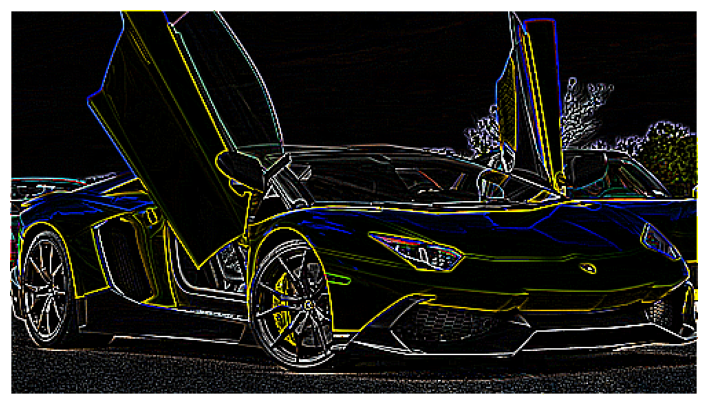

In [20]:
arr_hat = np.dstack((acts[0], acts[1], acts[2]))

plt.figure(figsize=(10, 5))
plt.imshow(arr_hat)
plt.axis("off")

Since we applied the edge detector on the three color channels separately, once we merge the results after the convolutions we obtain colorful edges of the car. Each colored edge that you see in the picture above is contributed by some degree of red edges detected in channel R, green edges detected in channel G, and blue edges in channel B.


## **Pooling** <a id="toc-pooling"></a>


### **What is Pooling?** <a id="toc-what-is-pooling"></a>

A CNN model may include local and/or global pooling layers along with traditional convolutional layers. It is a form of non-linear down-sampling to progressively **reduce the spatial size of the representation**, to **reduce the number of parameters**, **memory footprint and amount of computation in the network**, and hence to also **control overfitting**.

There are two common types of pooling in popular use: **Max Pooling** and **Average Pooling**. Max pooling outputs the maximum value of each sub-region in the feature map, while average pooling outputs the average value.

It is common to periodically insert a pooling layer between successive convolutional layers (each one typically followed by an activation function, such as a ReLU layer) in a CNN architecture. You can read more about Pooling [here](https://en.wikipedia.org/wiki/Convolutional_neural_network#Pooling_layer).

An illustration of **Max Pooling**:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/images/maxpooling.gif" width="1100"></center>


In tensorflow.keras, a **Pooling layer** downsamples the input along its spatial dimensions (height and width) by taking the maximum or average value over an input window (of size defined by `pool_size`) for each channel of the input.

You can add a Pooling layer to a CNN with **MaxPooling2D** or **AveragePooling2D**. Like a **Conv2D** layer, a Pooling layer also has arguments such as `padding` and `strides`, and they work in a same way as in a Conv2D layer. 


### **Example 3: Max or Average?** <a id="toc-example-3-max-or-average"></a>

- Max pooling **retains the most prominent features in the feature map**. It is useful when the background of the image is dark and we are interested in the lighter pixels of the image. For example, in the MNIST dataset, the digits are represented in white color and the background is black, so max pooling is more suitable.

- Average pooling **tends to smooth out the image**. Sometimes it cannot extract the important features because it takes everything into account, and gives an average value which may or may not be important. It shows a similar effect irrespective of the background.


Run the next cell to download the MNIST datset, which we will use to illustrate the difference between the output of Max Pooling and Average Pooling.


In [21]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("MNIST downloaded!")
print("Train set shape:", X_train.shape)

MNIST downloaded!
Train set shape: (60000, 28, 28)


Let's extract 5 random images from the train set and display them:


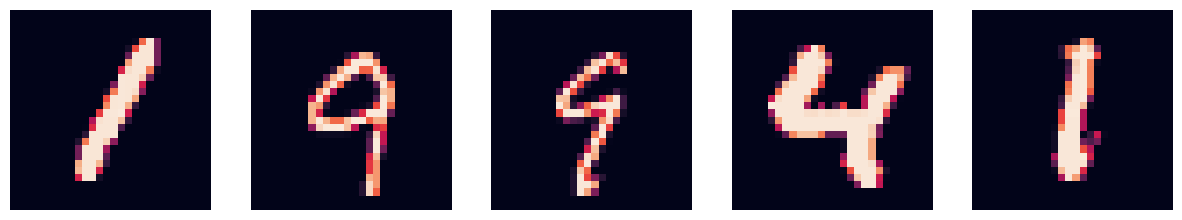

In [22]:
images = []
plt.figure(figsize=(15, 3))
for i in range(5):
    img = X_train[np.random.randint(0, 60000)].astype("float")
    images.append(img)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

Next we use our **max_pool** and **avg_pool** tool to perform pooling on these five images and see how their results appear differently.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


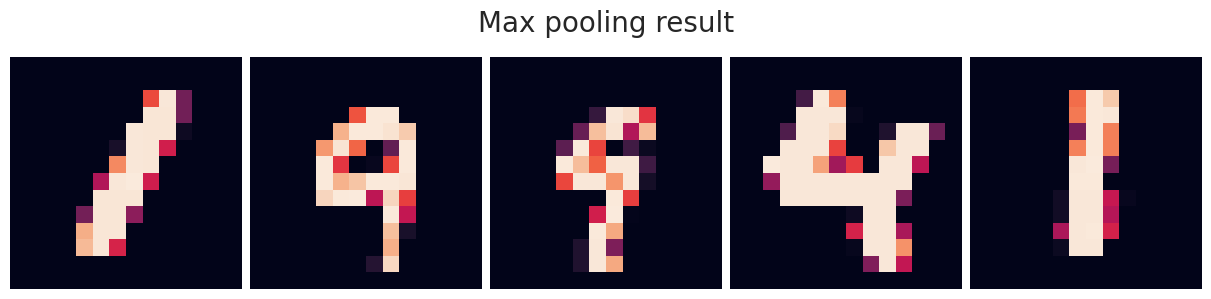

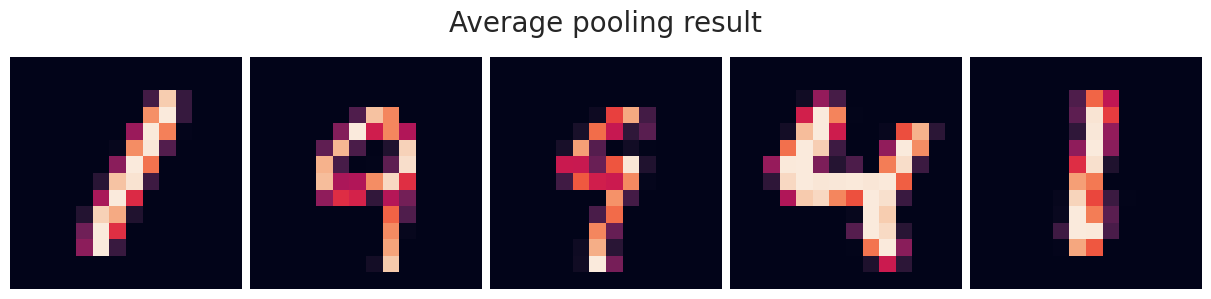

In [23]:
max_pool = keras.Sequential([MaxPooling2D(pool_size=(2, 2))])
avg_pool = keras.Sequential([AveragePooling2D(pool_size=(2, 2))])

fig1, axs1 = plt.subplots(1, 5, figsize=(12, 3), constrained_layout=True)
fig2, axs2 = plt.subplots(1, 5, figsize=(12, 3), constrained_layout=True)
fig1.suptitle("Max pooling result", fontsize=20)
fig2.suptitle("Average pooling result", fontsize=20)

for img, ax1, ax2 in zip(images, axs1.flat, axs2.flat):
    input_ = img.reshape(1, 28, 28, 1)
    ax1.imshow(max_pool.predict(input_).squeeze(0).squeeze(2))
    ax1.axis("off")
    ax2.imshow(avg_pool.predict(input_).squeeze(0).squeeze(2))
    ax2.axis("off")

As you can see, in max pooling the prominent features are highlighted more, whereas in average pooling it gives a smoother image retaining the complete features in the image.

We cannot say that one particular pooling method is better than the other generally. The choice of pooling operation should be made based on the problem at hand.


## **Exercises** <a id="toc-exercises"></a>

In this exercise, you will build a Convolutional Neural Network (CNN) to classify images from the well-known CIFAR-10 dataset.

The pre-defined `load_cifar10()` function returns a preprocessed version of the dataset where:

1. The pixel values in `X_train` and `X_test` are normalized into floating-point values.

2. The labels in `y_train` and `y_test` are one-hot encoded into 10-element binary vectors. Each vector contains a `1` at the position corresponding to the correct class and `0` elsewhere.

In [24]:
from keras.utils import to_categorical
from keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from keras.models import Sequential


def load_cifar10():
    (trainX, trainY), (testX, testY) = datasets.cifar10.load_data()

    trainX = trainX.astype("float32") / 255
    testX = testX.astype("float32") / 255

    trainY = to_categorical(trainY)
    testY = to_categorical(testY)

    return trainX, trainY, testX, testY

In [25]:
X_train, y_train, X_test, y_test = load_cifar10()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 10), (10000, 32, 32, 3), (10000, 10))

### **Exercise 1 - Display some images** <a id="toc-exercise-1-display-some-images"></a>

Write the code to display the first 25 images from the train set.


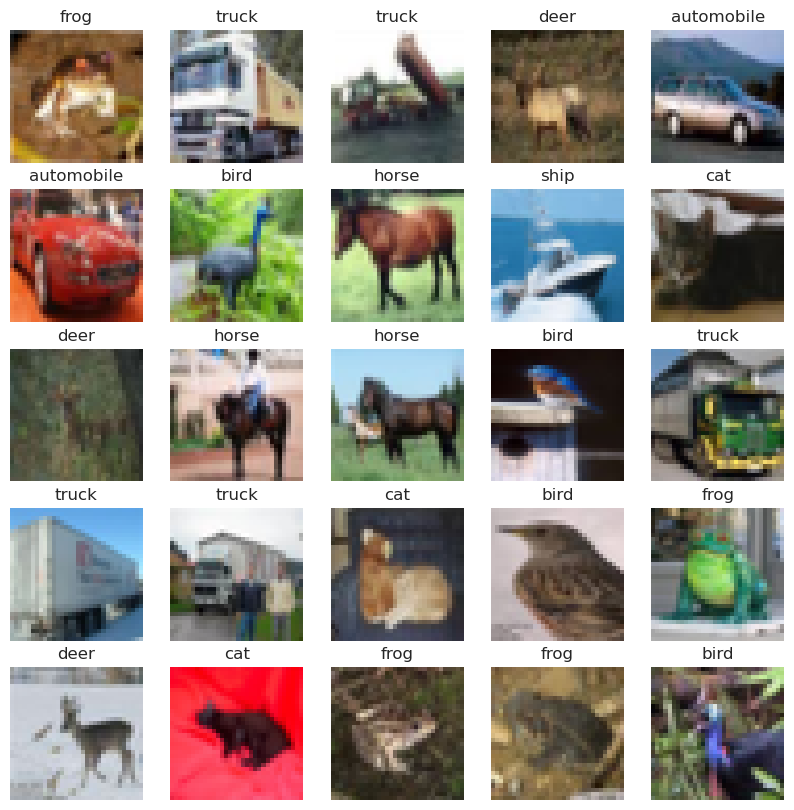

In [26]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]
plt.figure(figsize=(10, 10))
# TO DO

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

`np.argmax()` directly returns the index of the largest value, which is the position of 1 in a one-hot encoded vector.


### **Exercise 2 - Set up a Convolution layer** <a id="toc-exercise-2-set-up-a-convolution-layer"></a>

Create a Conv2D layer called **Conv** with 
- 32 $3\times3$ kernels
- `'he_uniform'` kernel initializer
- Padding
- ReLu activation


In [27]:
# TO DO
Conv = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    kernel_initializer="he_uniform",
    padding="same",
    activation="relu",
)

### **Exercise 3 - Set up a Max pooling layer** <a id="toc-exercise-3-set-up-a-max-pooling-layer"></a>

Create a MaxPooling2D layer with pool_size equal 2, name the single layer **Max**.


In [28]:
# TO DO
Max = layers.MaxPooling2D(pool_size=(2, 2))

<details>
    <summary>Click here for Solution</summary>

```python
Max = layers.MaxPooling2D(pool_size=(2,2))
```

</details>


### **Exercise 4 - Create a deeper CNN with blocks** <a id="toc-exercise-4-create-a-deeper-cnn-with-blocks"></a>

Now that you have practiced defining the two most commonly used layer types in a CNN, you can stack two **Conv2D** layers and one **MaxPooling2D** layer together as a block to build a deeper CNN with three such blocks.

As you move from one block to the next, it is common practice to increase the number of kernels (channels) in the Conv2D layers, often by doubling them.


First layer:
    specify input_shape

Remaining layers:
    Keras infers shapes automatically

In [29]:
# TO DO
model = Sequential()
model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
        input_shape=(32, 32, 3),
    )
)

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
    )
)
model.add(MaxPooling2D((2, 2)))

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
    )
)
model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
    )
)
model.add(MaxPooling2D((2, 2)))

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
    )
)
model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        kernel_initializer="he_uniform",
        padding="same",
    )
)
model.add(MaxPooling2D((2, 2)))

| Layer   | Output Shape |
| ------- | ------------ |
| Input   | 32×32×3      |
| Conv32  | 32×32×32     |
| Conv32  | 32×32×32     |
| MaxPool | 16×16×32     |
| Conv64  | 16×16×64     |
| Conv64  | 16×16×64     |
| MaxPool | 8×8×64       |
| Conv128 | 8×8×128      |
| Conv128 | 8×8×128      |
| MaxPool | 4×4×128      |


input_shape = (32, 32, 3) \
Height = 32 \
Width  = 32 \
Channels = 3 (RGB)

Conv2D(32, ...) Use 32 different filters

**NOTE**: Each filter looks at all RGB channels together. The 32 filters replace the OLD channel dimension (3), not the spatial dimensions (32×32).
So Input (32 × 32 × 3), Output(32 × 32 × 32)

- the spatial pixel grid (32×32) is preserved
- the original RGB channel representation is replaced by 32 learned feature channels

### **Optional section** <a id="toc-optional-section"></a>


You've accomplished a lot so far! Now just run the following cells to finish up building your CNN with some Dense layers. Don't worry if you don't know what the code does, as you will learn about Flattening and Dense layers in the next lab.


In [30]:
model.add(Flatten())
model.add(Dense(128, activation="relu", kernel_initializer="he_uniform"))
model.add(Dense(10, activation="softmax"))
model.summary()
# compile model
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

## **Authors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/) is a Data Scientist at IBM Skills Network.

Su Wu


## **Change Log**

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2020-07-17|0.1|Sam|Create Lab Template|
|2022-06-10|0.1|Roxanne Li|Create Lab|
|2026-05-19 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|


Copyright © 2022 IBM Corporation. All rights reserved.
